# Linear Regression Model

Suppose we have a raw dataset $\{(y_i,\vec{x}_i)\}$, where $\vec{x}_i = \{x_i^0,x_i^1,x_i^2...\}\Rightarrow y_i(\vec{x}_i)$. And we wanna fit this dataset into a function as 
$$
y(x) = g(x) + \epsilon
$$

if $g(\vec{x}_i) = \vec{\theta} \cdot \vec{x}_i = \theta_o x_i^0 + \theta_1 x_i^1... $, it will be called as linear model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from ucimlrepo import fetch_ucirepo 
auto_mpg = fetch_ucirepo(id=9) 
raw_data = auto_mpg.data.features 
label = auto_mpg.data.targets 
raw_data

---

机器学习-回归模型-数据预处理

In [ ]:
raw_data.insert(0, "supplement", 1, allow_duplicates=False)

In [ ]:
index = raw_data.isnull().sum()
n = 0
for d in index:
    if d != 0:
        print(f"there is null element that is found at '{raw_data.columns[n]}'")
        new_data = raw_data.dropna()
    n += 1
print("raw_data 是否有 NaN:", np.isnan(np.array(new_data)).any())
print("raw_data 是否有 inf:", np.isinf(np.array(new_data)).any())
print("new_data shape",new_data.shape)
new_data.columns

---
## Definition of Mian Loss Func

$L(\vec{\theta}) = \log(p(\epsilon_i)) =\text{m}\log\frac{1}{\sqrt{2\pi\sigma}} -\frac{1}{2\sigma^2} \sum_i^m \left[g(\vec{x}_i) - y(\vec{x}_i) \right]^2 \Rightarrow \tilde{L}(\vec{\theta}) = \text{m}\log\frac{1}{\sqrt{2\pi\sigma}} - \log(p(\epsilon_i))$

$$
\tilde{L}(\vec{\theta}) = \frac{1}{2\sigma^2} \sum_i^m \left[g(\vec{x}_i) - y(\vec{x}_i) \right]^2, g(\vec{x}_i) = \vec{\theta} \cdot \vec{x}_i
$$
where $g(\vec{x}_i) = \vec{\theta} \cdot \vec{x}_i = \theta_o x_i^0 + \theta_1 x_i^1... $


In [ ]:
def LossFunc(theta,raw_data,labels,sigma = 1.):
    temp = 0
    gxs   = theta @ np.array(raw_data).T  # theta[1xm] @ raw_data[mxn] -> 1xn =[gx1,gx2...]
    temp = [(gxs[n] - np.array(labels)[n])**2 for n in range(raw_data.shape[0]) ]           
    return 1/(2 * sigma**2) * np.sum(temp)

In [ ]:
theta = np.zeros(new_data.shape[1])
labelnp = np.array(label)
LossFunc(theta,new_data,label)  

In [ ]:
def random_thetas(theta_min,theta_max,samples,shape,centered=None,radius=None):
    if centered is not None and radius is not None:
        centered = np.array(centered)
        return  [np.random.normal(loc=thea, scale=radius) for thea in centered]
    else:
        return np.random.uniform(theta_min, theta_max, size=(samples,shape))

In [ ]:
random_thetas(-10,10,2,8,centered = [1,1,1,1,1,1,1,1],radius = 1)

In [70]:
# Preparing the initial theta samples, the number of gaussing samples = 100
num_thes = new_data.shape[1]
max_thes = 1000
min_thes = -1000
num_inth = 10000
thets    = random_thetas(theta_min = min_thes,
                         theta_max = max_thes,
                         samples   = num_inth,
                         shape     = num_thes)

# run the first iteration
Lof1 = np.array([])   
Lof_idxs1 = np.array([])   
for n,th in enumerate(thets):
    lofc = LossFunc( theta    = th,
                     raw_data = new_data,
                     labels   = label)
    
    Lof1 = np.append(Lof1,lofc)
    min_loss = np.min(Lof1)
    min_idx  = np.argmin(Lof1)
    Lof_idxs1 = np.append(Lof_idxs1,min_idx)
    print(f"{n}/{num_inth}", f"the smallest LoF arrpearing at {min_idx+1}, with min/max={np.min(Lof1)/np.max(Lof1)}")
corrdinates = set(Lof_idxs1)
thets    = thets[min_idx]

0/10000 the smallest LoF arrpearing at 1, with min/max=1.0
1/10000 the smallest LoF arrpearing at 1, with min/max=0.6000157563746038
2/10000 the smallest LoF arrpearing at 3, with min/max=0.13271558558163882
3/10000 the smallest LoF arrpearing at 3, with min/max=0.13271558558163882
4/10000 the smallest LoF arrpearing at 3, with min/max=0.132203549709407
5/10000 the smallest LoF arrpearing at 6, with min/max=0.03224511043625536
6/10000 the smallest LoF arrpearing at 7, with min/max=0.0015704579332887774
7/10000 the smallest LoF arrpearing at 7, with min/max=0.0015704579332887774
8/10000 the smallest LoF arrpearing at 7, with min/max=0.0015704579332887774
9/10000 the smallest LoF arrpearing at 7, with min/max=0.0015704579332887774
10/10000 the smallest LoF arrpearing at 11, with min/max=0.00018403232184213068
11/10000 the smallest LoF arrpearing at 11, with min/max=0.00018403232184213068
12/10000 the smallest LoF arrpearing at 11, with min/max=0.00018403232184213068
13/10000 the smallest

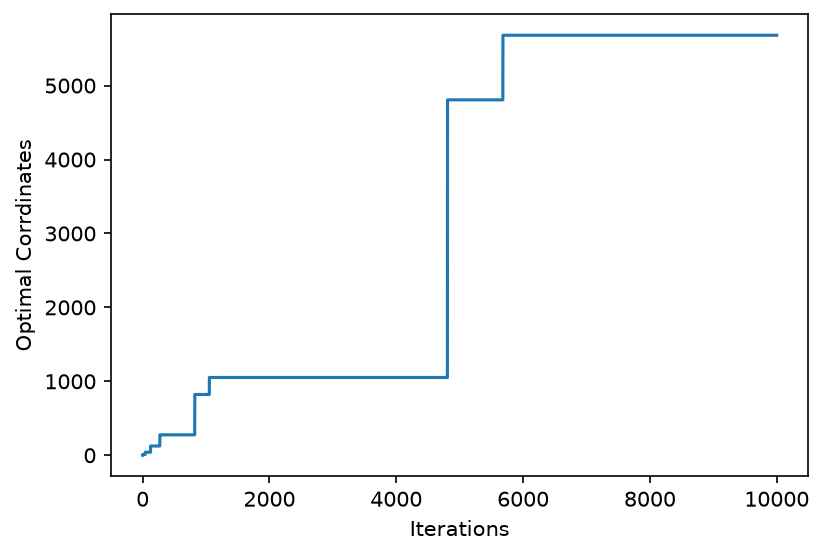

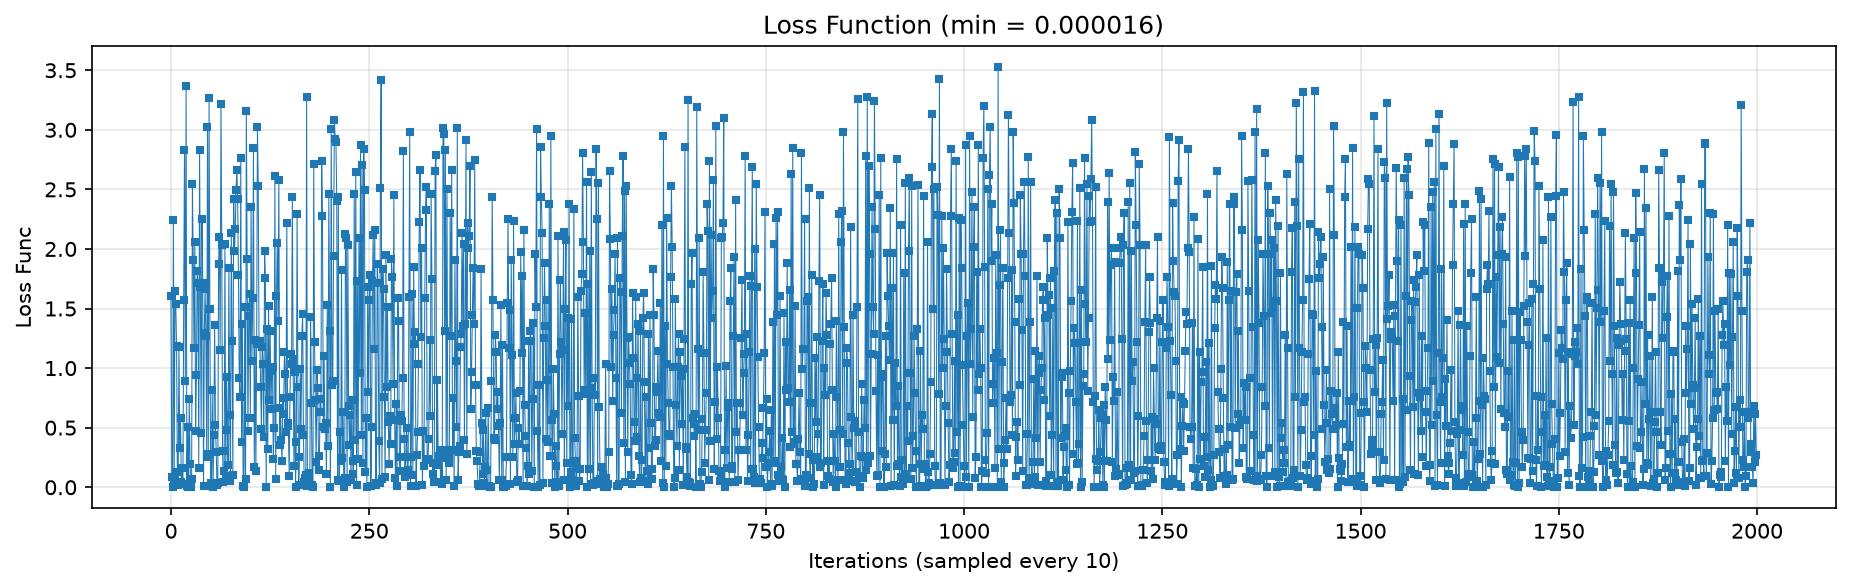

In [86]:
plt.figure(figsize=(6,4),dpi=150)
plt.plot(range(len(Lof_idxs1)),Lof_idxs1)
plt.xlabel("Iterations")
plt.ylabel("Optimal Corrdinates")
plt.show()
mean = np.mean(Lof1)
plt.figure(figsize=(15, 4), dpi=150)
plt.plot(range(len(Lof1[::5])), (Lof1/mean)[::5], lw=0.5, marker='s', ms=3)
plt.xlabel("Iterations (sampled every 10)")
plt.ylabel("Loss Func")
plt.title(f"Loss Function (min = {np.min(Lof1)/np.mean(Lof1):.6f})")
plt.grid(True, alpha=0.3)
plt.show()

In [87]:
corrdinates

{np.float64(0.0),
 np.float64(2.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(10.0),
 np.float64(41.0),
 np.float64(125.0),
 np.float64(271.0),
 np.float64(276.0),
 np.float64(822.0),
 np.float64(1052.0),
 np.float64(4807.0),
 np.float64(5681.0)}